# Mô hình dự báo doanh thu: Pipeline, Kiểm tra tuân thủ quy định, Cross-validation, SHAP Explainability
### Nhóm: Nếu cả đời không rực rỡ thì sao
---
# Cấu trúc của notebook

| Part | Section | Nội dung |
|---|---|---|
| **PART 1** | 1.1 Setup | Import libraries cần thiết, điều chỉnh mô hình LightGBM |
| | 1.2 Data | Load data, xây dựng segment + category daily series |
| | 1.3 Features | Feature engineering |
| | 1.4 Training | Xây dựng hàm training/prediction cho cả 2 branch |
| | 1.5 Segment branch | Dự đoán Revenue qua 8 segments |
| | 1.6 Category branch | Dự đoán Revenue qua 4 categories |
| | 1.7 Blend | Kết hợp dự đoán của 2 branch với weight 50/50 (submission) |
| **PART 2** | 2.1 Compliance | Kiểm tra tuân thủ quy định |
| | 2.2 Cross-validation | Sử dụng Rolling-origin time-series CV cho mô hình ở Part 1|
| | 2.3 SHAP | Global importance + summary plots + waterfall explanations |
| | 2.4 Integrity | Sử dụng SHA-256 hash cho submission.csv |

# PART 1: PIPELINE

## 1.1 Setup


In [2]:
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display,Markdown 
import os
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import seaborn as sns

try:
    import shap
except ImportError:
    shap = None
    print("Note: SHAP not installed. Install with: pip install shap")

def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'<br>{s}'
    else:
        s = f'<br>{s}'
    display( Markdown(s) )

# Khả năng tái lập
print("Library versions để đảm bảo tái lập:")
import sklearn
print(f"  numpy:    {np.__version__}")
print(f"  pandas:   {pd.__version__}")
print(f"  sklearn:  {sklearn.__version__}")
print(f"  lightgbm: {lgb.__version__}")
print(f"  seaborn:  {sns.__version__}")
if shap is not None:
    print(f"  shap:     {shap.__version__}")


Library versions để đảm bảo tái lập:
  numpy:    1.26.4
  pandas:   2.2.2
  sklearn:  1.5.1
  lightgbm: 4.6.0
  seaborn:  0.13.2
  shap:     0.45.1


In [3]:
HORIZON             = 548
TEST_DAYS           = 548
RECENT_HOLDOUT_DAYS = 180
BOOST_WINDOW_DAYS   = 730
BOOST_MULTIPLIER    = 3.0
RANDOM_SEED = 42

LGBM_PARAMS = {
    "objective":"regression", "metric":"mae",
    "num_leaves":31, "min_data_in_leaf":20,
    "learning_rate":0.05, "feature_fraction":0.8,
    "bagging_fraction":0.8, "bagging_freq":5,
    "lambda_l1":0.1, "lambda_l2":0.1,
    "verbose":-1, "n_jobs":-1,
}
NUM_BOOST_ROUND = 500

TET_DAY_1 = {
    2012: pd.Timestamp('2012-01-23'), 2013: pd.Timestamp('2013-02-10'),
    2014: pd.Timestamp('2014-01-31'), 2015: pd.Timestamp('2015-02-19'),
    2016: pd.Timestamp('2016-02-08'), 2017: pd.Timestamp('2017-01-28'),
    2018: pd.Timestamp('2018-02-16'), 2019: pd.Timestamp('2019-02-05'),
    2020: pd.Timestamp('2020-01-25'), 2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'), 2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'), 2025: pd.Timestamp('2025-01-29'),
}

def nearest_tet(date):
    y = date.year
    candidates = [TET_DAY_1.get(y-1), TET_DAY_1.get(y), TET_DAY_1.get(y+1)]
    candidates = [c for c in candidates if c is not None]
    return min(candidates, key=lambda t: abs((t - date).days))


---
## 1.2 Data Loading và Reconstruction

Load 4/15 CSVs được cung cấp bởi BTC. Sử dụng công thức `order_items × products` để build Revenue và COGS time series theo 2 nhóm:

- **Segment level** (8 series): Activewear, All-weather, Balanced, Everyday, Performance, Premium, Standard, Trendy
- **Category level** (4 series): Casual, GenZ, Outdoor, Streetwear

Cả 2 nhóm đều có tổng bằng `sales.csv` Revenue/COGS (được tính qua MAE = 0 ở Part 2).


In [4]:
# Tải dữ liệu gốc được dùng cho cả nhánh segment và category
print("Đang tải dữ liệu gốc...")
items_raw = pd.read_csv('order_items.csv', dtype={'promo_id_2':'object'})
orders    = pd.read_csv('orders.csv', parse_dates=['order_date'])
products  = pd.read_csv('products.csv').rename(columns={'cogs':'prod_cogs'})
sales     = pd.read_csv('sales.csv', parse_dates=['Date'])

# Kết hợp order_items với thông tin sản phẩm và ngày đơn hàng
items_p = items_raw.merge(products[['product_id','category','segment','prod_cogs']],
                          on='product_id', how='left')
items_p['gross_rev']  = items_p['quantity'] * items_p['unit_price']
items_p['gross_cogs'] = items_p['quantity'] * items_p['prod_cogs']
items_p_dated = items_p.merge(orders[['order_id','order_date']], on='order_id', how='left')
items_p_dated['ds'] = items_p_dated['order_date'].dt.normalize()

# Xây dựng chuỗi dữ liệu theo ngày ở cấp segment
daily_rev_by_seg  = items_p_dated.groupby(['ds','segment'])['gross_rev'].sum().unstack(fill_value=0)
daily_cogs_by_seg = items_p_dated.groupby(['ds','segment'])['gross_cogs'].sum().unstack(fill_value=0)

# Xây dựng chuỗi dữ liệu theo ngày ở cấp category
daily_rev_by_cat  = items_p_dated.groupby(['ds','category'])['gross_rev'].sum().unstack(fill_value=0)
daily_cogs_by_cat = items_p_dated.groupby(['ds','category'])['gross_cogs'].sum().unstack(fill_value=0)

# Reindex về dải ngày liên tục (điền các ngày thiếu bằng 0)
full_range = pd.date_range(sales['Date'].min(), sales['Date'].max(), freq='D')
for label, df in [
    ('seg_rev', daily_rev_by_seg), ('seg_cogs', daily_cogs_by_seg),
    ('cat_rev', daily_rev_by_cat), ('cat_cogs', daily_cogs_by_cat),
]:
    pass  # placeholder; reindexing below
daily_rev_by_seg  = daily_rev_by_seg.reindex(full_range, fill_value=0); daily_rev_by_seg.index.name='ds'
daily_cogs_by_seg = daily_cogs_by_seg.reindex(full_range, fill_value=0); daily_cogs_by_seg.index.name='ds'
daily_rev_by_cat  = daily_rev_by_cat.reindex(full_range, fill_value=0); daily_rev_by_cat.index.name='ds'
daily_cogs_by_cat = daily_cogs_by_cat.reindex(full_range, fill_value=0); daily_cogs_by_cat.index.name='ds'

SEGMENTS = list(daily_rev_by_seg.columns)
CATEGORIES = list(daily_rev_by_cat.columns)
print(f"Segments ({len(SEGMENTS)}): {SEGMENTS}")
print(f"Categories ({len(CATEGORIES)}): {CATEGORIES}")
print(f"Series length: {len(daily_rev_by_seg)} days "
      f"({daily_rev_by_seg.index.min().date()} -> {daily_rev_by_seg.index.max().date()})")


Đang tải dữ liệu gốc...
Segments (8): ['Activewear', 'All-weather', 'Balanced', 'Everyday', 'Performance', 'Premium', 'Standard', 'Trendy']
Categories (4): ['Casual', 'GenZ', 'Outdoor', 'Streetwear']
Series length: 3833 days (2012-07-04 -> 2022-12-31)


---
## 1.3 Feature Engineering

`make_features()` function được áp dụng cho 12 model LightGBM tương ứng (8 segment + 4 category models). 3 feature được sử dụng để dự đoán:

| Feature | Ví dụ | Mục đích |
|---|---|---|
| Calendar | `dow`, `month`, `quarter`, `dow_sin/cos`, `month_sin/cos`, `is_weekend`, `is_month_end` | Seasonality |
| Vietnamese cycles | days_to_tet, is_tet_week, is_tet_pre_ramp, is_tet_holiday_period; is_month_boundary_window, days_to_month_boundary, month_boundary_intensity, is_mid_month_low | Lịch âm (Tết) và effect của các ngày trong tháng |
| Lag/rolling | `lag_{1..365}`, `roll_mean_{7..365}`, `roll_std_{7..365}`, `wow_growth`, `yoy_growth` | Autocorrelation và trends   |

Tất cả lag/rolling features sử dụng `.shift(1)` —> ép model không được biết trước chỉ số của ngày hôm nay trong quá trình dự đoán ngày đó.


In [5]:
def make_features(df):
    """Build feature matrix for any daily revenue or COGS series.
    df must have columns 'ds' (datetime) and 'y' (target)."""
    d = df.copy()

    # Feature calendar (chỉ tính ngày, không phụ thuộc target)
    d["dow"] = d["ds"].dt.dayofweek
    d["month"] = d["ds"].dt.month
    d["quarter"] = d["ds"].dt.quarter
    d["day_of_month"] = d["ds"].dt.day
    d["week_of_year"] = d["ds"].dt.isocalendar().week.astype(int)
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_month_end"] = d["ds"].dt.is_month_end.astype(int)
    d["dow_sin"] = np.sin(2*np.pi*d["dow"]/7)
    d["dow_cos"] = np.cos(2*np.pi*d["dow"]/7)
    d["month_sin"] = np.sin(2*np.pi*d["month"]/12)
    d["month_cos"] = np.cos(2*np.pi*d["month"]/12)

    # Feature ranh giới, chu kỳ tháng (chỉ dựa vào ngày trong tháng, không phụ thuộc target)
    dom = d["day_of_month"]
    d["is_month_boundary_window"]    = ((dom >= 28) | (dom == 1)).astype(int)
    d["is_mid_month_low"]     = ((dom >= 3) & (dom <= 6)).astype(int)
    d["days_to_month_boundary"] = np.minimum((dom-30).abs(), (dom+1).abs())
    d["month_boundary_intensity"]    = np.exp(-d["days_to_month_boundary"]/5.0)
    d["is_first_3_days"]     = (dom <= 3).astype(int)
    d["is_last_4_days"]      = (dom >= 28).astype(int)

    # Feature Tết (tra cứu lịch âm, không phụ thuộc target)
    tet_dates = d["ds"].apply(nearest_tet)
    delta = (d["ds"] - tet_dates).dt.days
    d["days_to_tet"] = delta
    d["abs_days_to_tet"] = delta.abs()
    d["is_tet_week"] = (delta.abs() <= 3).astype(int)
    d["is_tet_holiday_period"] = ((delta >= 0) & (delta <= 7)).astype(int)
    d["is_tet_pre_ramp"] = ((delta >= -14) & (delta < 0)).astype(int)

    # Feature lag và rolling — .shift(1) giúp tránh rò rỉ target
    for lag in [1, 2, 3, 7, 14, 30, 90, 180, 365]:
        d[f"lag_{lag}"] = d["y"].shift(lag)
    for window in [7, 14, 30, 90, 365]:
        d[f"roll_mean_{window}"] = d["y"].shift(1).rolling(window).mean()
        d[f"roll_std_{window}"]  = d["y"].shift(1).rolling(window).std()
    d["wow_growth"] = d["y"].shift(1) / (d["y"].shift(8)   + 1e-9) - 1
    d["yoy_growth"] = d["y"].shift(1) / (d["y"].shift(366) + 1e-9) - 1

    feature_cols = [c for c in d.columns if c != "y"]
    return d.dropna(subset=feature_cols).reset_index(drop=True)


def get_feature_cols(df):
    return [c for c in df.columns if c not in ("ds", "y")]


---
## 1.4 Các hàm Training và Prediction

Các hàm dưới đây được sử dụng để train/predict cho cả 2 branch (segment và category):

- `weights_window_boost`: assign weight = 3.0 cho các ngày gần đây (730 ngày), còn lại được assign weight = 1.0
- `fit_lgbm`: train mô hình LightGBM sử dụng `LGBM_PARAMS` và sample weights
- `predict_recursive`: dự đoán forward day-by-day, liên tục feed các prediction đã hoàn thành lại vào lag features
- `forecast_one_series`: Wrapper (hàm bao) end-to-end, nhận vào một chuỗi dữ liệu theo ngày và các ngày mục tiêu rồi tạo ra dự đoán.


In [6]:
def weights_window_boost(feat_df, window_days=BOOST_WINDOW_DAYS, multiplier=BOOST_MULTIPLIER):
    """Gán weight cho các dữ liệu gần đây (recency-weighted samples): các dòng nằm trong window_days gần nhất sẽ được nhân trọng số lên multiplier lần."""
    ref = feat_df["ds"].max()
    age = (ref - feat_df["ds"]).dt.days.values.astype(float)
    w = np.ones(len(feat_df))
    w[age <= window_days] = multiplier
    return w


def fit_lgbm(feat_df, feat_cols, weights):
    """Fit model LightGBM với 1 chuỗi."""
    dtrain = lgb.Dataset(feat_df[feat_cols].values,
                         label=feat_df["y"].values,
                         weight=weights, feature_name=feat_cols)
    return lgb.train(LGBM_PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)


def predict_recursive(model, history_df, future_dates, feat_cols):
    """Dự báo đệ quy theo từng ngày. Mỗi dự báo được thêm vào history,
    vì vậy các feature lag/rolling cho ngày t+1 sẽ sử dụng chính dự báo của mô hình ở ngày t."""
    hist = history_df[["ds","y"]].copy()
    preds = []
    for future_date in future_dates:
        row = pd.DataFrame({"ds":[future_date], "y":[np.nan]})
        combined = pd.concat([hist, row], ignore_index=True)
        combined = make_features(combined.tail(500))
        if combined["ds"].iloc[-1] != future_date:
            # Fallback if make_features dropped the row (shouldn't happen but be safe)
            pred_val = float(hist["y"].tail(7).mean())
        else:
            X_pred = combined.iloc[[-1]][feat_cols]
            pred_val = float(model.predict(X_pred)[0])
        pred_val = max(0, pred_val)
        preds.append(pred_val)
        hist = pd.concat([hist, pd.DataFrame({"ds":[future_date], "y":[pred_val]})],
                         ignore_index=True)
    return np.array(preds)


def forecast_one_series(daily_series, future_dates):
    df_s = daily_series.rename('y').reset_index()
    feat_train = make_features(df_s)
    feat_cols = get_feature_cols(feat_train)
    w = weights_window_boost(feat_train)
    model = fit_lgbm(feat_train, feat_cols, w)
    preds = predict_recursive(model, df_s, future_dates, feat_cols)
    return preds, model


---
## 1.5 Branch A: Segment-level Bottom-Up Forecast

Dự báo riêng từng segment (8 segment), sau đó cộng lại để ra tổng doanh thu. Áp dụng cách tương tự cho COGS.


In [7]:
# Xác định khoảng ngày tương lai (cửa sổ dự báo 548 ngày của cuộc thi)
last_date = daily_rev_by_seg.index.max()
future_dates = pd.date_range(last_date + timedelta(days=1), periods=HORIZON, freq='D')

print("Branch A: Dự đoán trên mức Segment")
print(f"Đang train data trên {len(daily_rev_by_seg)} ngày, dự đoán {HORIZON} ngày tiếp theo...")

print("\nĐang dự đoán Revenue theo segment..")
seg_preds_future = {}
for seg in SEGMENTS:
    preds, _ = forecast_one_series(daily_rev_by_seg[seg], future_dates)
    seg_preds_future[seg] = preds
    print(f"  {seg:<14}  forecast mean = {preds.mean():>12,.0f}")

print("\nĐang dự đoán COGS theo segment...")
seg_cogs_future = {}
for seg in SEGMENTS:
    preds, _ = forecast_one_series(daily_cogs_by_seg[seg], future_dates)
    seg_cogs_future[seg] = preds

total_rev_future_seg  = np.sum(list(seg_preds_future.values()), axis=0)
total_cogs_future_seg = np.sum(list(seg_cogs_future.values()),  axis=0)

out_seg = pd.DataFrame({
    "Date":    future_dates,
    "Revenue": np.round(np.clip(total_rev_future_seg,  0, None), 4),
    "COGS":    np.round(np.clip(total_cogs_future_seg, 0, None), 4),
})

Branch A: Dự đoán trên mức Segment
Đang train data trên 3833 ngày, dự đoán 548 ngày tiếp theo...

Đang dự đoán Revenue theo segment..
  Activewear      forecast mean =      221,209
  All-weather     forecast mean =      182,873
  Balanced        forecast mean =    1,738,776
  Everyday        forecast mean =    1,071,306
  Performance     forecast mean =      563,442
  Premium         forecast mean =       73,096
  Standard        forecast mean =       54,847
  Trendy          forecast mean =      121,599

Đang dự đoán COGS theo segment...


---
## 1.6 Branch B: Category-level Bottom-Up Forecast

Sử dụng phương pháp tương tự Branch A, nhưng với category (4 category).


In [8]:
print("Branch B: Dự đoán theo mức Category")
print(f"Đang train data trên {len(daily_rev_by_seg)} ngày, dự đoán {HORIZON} ngày tiếp theo...")

print("\nĐang dự đoán Revenue theo segment..")
cat_preds_future = {}
for cat in CATEGORIES:
    preds, _ = forecast_one_series(daily_rev_by_cat[cat], future_dates)
    cat_preds_future[cat] = preds
    print(f"  {cat:<12}  forecast mean = {preds.mean():>12,.0f}")

print("\nĐang dự đoán COGS theo segment..")
cat_cogs_future = {}
for cat in CATEGORIES:
    preds, _ = forecast_one_series(daily_cogs_by_cat[cat], future_dates)
    cat_cogs_future[cat] = preds

total_rev_future_cat  = np.sum(list(cat_preds_future.values()), axis=0)
total_cogs_future_cat = np.sum(list(cat_cogs_future.values()),  axis=0)

out_cat = pd.DataFrame({
    "Date":    future_dates,
    "Revenue": np.round(np.clip(total_rev_future_cat,  0, None), 4),
    "COGS":    np.round(np.clip(total_cogs_future_cat, 0, None), 4),
})

Branch B: Dự đoán theo mức Category
Đang train data trên 3833 ngày, dự đoán 548 ngày tiếp theo...

Đang dự đoán Revenue theo segment..
  Casual        forecast mean =      223,600
  GenZ          forecast mean =      121,599
  Outdoor       forecast mean =      319,426
  Streetwear    forecast mean =    3,083,178

Đang dự đoán COGS theo segment..


---
## 1.7 Final Blend: 50/50 Ensemble

Kết hợp dự đoán của ensemble (8 branch segment + 4 branch category) với weight 50/50 (submission).


In [9]:
# Blend 50/50 cuối cùng tạo ra submission
def make_blend(df_a, df_b, w_a, w_b):
    """Trung bình weight của hai DataFrame submission, được căn chỉnh theo cột Date."""
    assert abs(w_a + w_b - 1) < 1e-6, "Weights must sum to 1"
    df = df_a.merge(df_b, on="Date", suffixes=("_a", "_b"))
    out = pd.DataFrame({
        "Date":    df["Date"],
        "Revenue": np.round(w_a * df["Revenue_a"] + w_b * df["Revenue_b"], 4),
        "COGS":    np.round(w_a * df["COGS_a"]    + w_b * df["COGS_b"],    4),
    })
    out["Revenue"] = np.clip(out["Revenue"], 0, None)
    out["COGS"]    = np.clip(out["COGS"],    0, None)
    return out


submission = make_blend(out_seg, out_cat, 0.5, 0.5)
submission.to_csv("submission.csv", index=False)

print("="*70)
print("FINAL SUBMISSION")
print("="*70)
print(f"  File:        submission.csv")
print(f"  Rows:        {len(submission)}")
print(f"  Date range:  {submission['Date'].iloc[0]} -> {submission['Date'].iloc[-1]}")
print(f"  Revenue:     mean={submission['Revenue'].mean():,.0f}  max={submission['Revenue'].max():,.0f}")
print(f"  COGS:        mean={submission['COGS'].mean():,.0f}  max={submission['COGS'].max():,.0f}")


FINAL SUBMISSION
  File:        submission.csv
  Rows:        548
  Date range:  2023-01-01 00:00:00 -> 2024-07-01 00:00:00
  Revenue:     mean=3,887,476  max=10,733,352
  COGS:        mean=3,451,052  max=9,908,730


---
# PART 2: ANALYSIS

Tất cả nội dung bên dưới sẽ phân tích mô hình và file submission được tạo ở Phần 1. Các biến dùng trong Phần 2 (daily_rev_by_seg, daily_rev_by_cat, submission, make_features, fit_lgbm, …) là các biến đã tạo ra submission cuối cùng.

2.1 Kiểm tra tuân thủ (Compliance Audit)

Quy định cuộc thi sẽ loại (disqualify) bất kỳ submission nào nếu:

- Sử dụng Revenue hoặc COGS của giai đoạn test làm feature
- Sử dụng dữ liệu bên ngoài ngoài 15 file CSV được cung cấp
- Không thể tái lập (reproduce) lại kết quả

4 kiểm tra tự động bên dưới dựa theo quy định cuộc thi, và khi kiểm tra sẽ in ra PASS hoặc FAIL kèm lý do.

In [10]:
# ── COMPLIANCE CHECK 1: Revenue/COGS reconstruction ────────────────────────
print("="*70)
print("CHECK 1: Tái lập kết quả của Revenue và COGS từ order_items + products")
print("="*70)

rev_recon_total  = daily_rev_by_seg.sum(axis=1)
cogs_recon_total = daily_cogs_by_seg.sum(axis=1)
joined = (sales.set_index('Date')
              .join(rev_recon_total.rename('rev_recon'))
              .join(cogs_recon_total.rename('cogs_recon')))
mae_rev  = (joined['Revenue'] - joined['rev_recon']).abs().mean()
mae_cogs = (joined['COGS']    - joined['cogs_recon']).abs().mean()
print(f"  Revenue tái lập MAE: {mae_rev:.4f}")
print(f"  COGS tái lập MAE:    {mae_cogs:.4f}")
if mae_rev < 1.0 and mae_cogs < 1.0:
    print(f"  PASS - sales.csv Revenue = sum(quantity * unit_price) với tất cả order_status")
    print(f"  PASS - sales.csv COGS    = sum(quantity * cogs_from_products)")
else:
    print(f"  FAIL - tái lập không trùng khớp")


CHECK 1: Tái lập kết quả của Revenue và COGS từ order_items + products
  Revenue tái lập MAE: 0.0000
  COGS tái lập MAE:    0.0025
  PASS - sales.csv Revenue = sum(quantity * unit_price) với tất cả order_status
  PASS - sales.csv COGS    = sum(quantity * cogs_from_products)


In [11]:
# ── COMPLIANCE CHECK 2 ──────────────────────────

print("="*70)
print("CHECK 2: Kiểm tra features được sử dụng")
print("="*70)

FEATURE_FAMILIES = {
    'calendar':    ['dow','month','quarter','day_of_month','week_of_year','is_weekend','is_month_end',
                    'dow_sin','dow_cos','month_sin','month_cos'],
    'tet_holiday': ['is_tet_pre_ramp', 'is_tet_holiday_period', 'is_tet_week', 'abs_days_to_tet', 'days_to_tet'],
    'Ranh giới tháng':      ['is_month_boundary_window','is_mid_month_low','days_to_month_boundary','month_boundary_intensity',
                    'is_first_3_days','is_last_4_days'],
    'lag_rolling': [f'lag_{l}' for l in [1,2,3,7,14,30,90,180,365]] +
                   [f'roll_mean_{w}' for w in [7,14,30,90,365]] +
                   [f'roll_std_{w}'  for w in [7,14,30,90,365]] +
                   ['wow_growth','yoy_growth'],
}

# Xác minh rằng mô hình thực tế chỉ sử dụng các feature này
sample_seg_features = make_features(daily_rev_by_seg['Balanced'].rename('y').reset_index())
actual_features = set(get_feature_cols(sample_seg_features))
declared_features = set(sum(FEATURE_FAMILIES.values(), []))

print("Bộ features được sử dụng:")
for family, feats in FEATURE_FAMILIES.items():
    print(f"  {family:<15} ({len(feats)} features)")

# Cross-check
undeclared = actual_features - declared_features
unused = declared_features - actual_features
print(f"\nVerification:")
print(f"  Số feature thực tế trong model:    {len(actual_features)}")
print(f"  Số feature khai báo trong audit:  {len(declared_features)}")
if not undeclared and not unused:
    print(f"  PASS - danh sách feature khớp hoàn toàn với model")
else:
    if undeclared: print(f"  CẢNH BÁO - phát hiện feature chưa khai báo: {undeclared}")
    if unused:     print(f"  CẢNH BÁO - feature đã khai báo nhưng không dùng trong model: {unused}")

print("\nĐánh giá nguồn gốc feature:")
print("  - calendar:    suy ra hoàn toàn từ chỉ số ngày -> KHÔNG phụ thuộc vào target")
print("  - tet_holiday: suy ra từ dictionary Tết hardcode -> KHÔNG phụ thuộc vào target")
print("  - day-of-month:      suy ra từ ngày trong tháng -> KHÔNG phụ thuộc vào target")
print("  - lag_rolling: suy ra từ chuỗi đang dự báo, có shift(1) nghiêm ngặt")
print("                 (lag_1 là ngày hôm qua; không bao giờ truy cập hôm nay hoặc tương lai khi train)")
print("\n  PASS - không có feature nào sử dụng Revenue hoặc COGS ngoài phạm vi dữ liệu training")


CHECK 2: Kiểm tra features được sử dụng
Bộ features được sử dụng:
  calendar        (11 features)
  tet_holiday     (5 features)
  Ranh giới tháng (6 features)
  lag_rolling     (21 features)

Verification:
  Số feature thực tế trong model:    43
  Số feature khai báo trong audit:  43
  PASS - danh sách feature khớp hoàn toàn với model

Đánh giá nguồn gốc feature:
  - calendar:    suy ra hoàn toàn từ chỉ số ngày -> KHÔNG phụ thuộc vào target
  - tet_holiday: suy ra từ dictionary Tết hardcode -> KHÔNG phụ thuộc vào target
  - day-of-month:      suy ra từ ngày trong tháng -> KHÔNG phụ thuộc vào target
  - lag_rolling: suy ra từ chuỗi đang dự báo, có shift(1) nghiêm ngặt
                 (lag_1 là ngày hôm qua; không bao giờ truy cập hôm nay hoặc tương lai khi train)

  PASS - không có feature nào sử dụng Revenue hoặc COGS ngoài phạm vi dữ liệu training


In [12]:
# ── COMPLIANCE CHECK 3 ──────────────────────────────────
print("="*70)
print("CHECK 3: Kiểm tra nguồn Data source")
print("="*70)

ALLOWED_FILES = {
    'products.csv', 'customers.csv', 'promotions.csv', 'geography.csv',
    'orders.csv', 'order_items.csv', 'payments.csv', 'shipments.csv',
    'returns.csv', 'reviews.csv', 'sales.csv', 'sample_submission.csv',
    'inventory.csv', 'inventory_enhanced.csv', 'web_traffic.csv',
}

# Các tệp thực sự được sử dụng trong pipeline này (hiển thị ở cell 1.2)
USED_FILES = {'order_items.csv', 'orders.csv', 'products.csv', 'sales.csv'}

print("Pipeline chỉ sử dụng các file sau:")
for f in sorted(USED_FILES):
    status = "OK" if f in ALLOWED_FILES else "EXTERNAL"
    print(f"  {status}  {f}")

external = USED_FILES - ALLOWED_FILES
if not external:
    print(f"\n  PASS - tất cả dữ liệu lấy từ dataset của cuộc thi")
else:
    print(f"\n  FAIL - phát hiện dữ liệu ngoài: {external}")

print(f"\nNote: Ngày Tết 2012-2025 được harcoded từ lịch âm.")
print(f"      Lịch là kiến thức công khai và mang tính xác định.")
print(f"      Theo luật thi, tra cứu lịch không vi phạm sử dụng dữ liệu ngoài.")

CHECK 3: Kiểm tra nguồn Data source
Pipeline chỉ sử dụng các file sau:
  OK  order_items.csv
  OK  orders.csv
  OK  products.csv
  OK  sales.csv

  PASS - tất cả dữ liệu lấy từ dataset của cuộc thi

Note: Ngày Tết 2012-2025 được harcoded từ lịch âm.
      Lịch là kiến thức công khai và mang tính xác định.
      Theo luật thi, tra cứu lịch không vi phạm sử dụng dữ liệu ngoài.


In [13]:
# ── COMPLIANCE CHECK 4 ──────────────────
print("="*70)
print("CHECK 4: Khoảng thời gian dữ liệu huấn luyện")
print("="*70)

train_cutoff = pd.Timestamp('2022-12-31')
print(f"Mốc kết thúc train (theo quy định cuộc thi): {train_cutoff.date()}")

for label, series in [
    ('segment series', daily_rev_by_seg),
    ('category series', daily_rev_by_cat),
]:
    last_date = series.index.max()
    if last_date <= train_cutoff:
        print(f"  PASS - {label}: last observation = {last_date.date()}")
    else:
        print(f"  FAIL - {label}: contains observations after cutoff!")

# Kiểm tra: future_dates (dùng để dự báo) bắt đầu sau mốc cutoff
print(f"\n  Khoảng dự báo: {future_dates[0].date()} -> {future_dates[-1].date()}")
print(f"  Dữ liệu train kết thúc: {daily_rev_by_seg.index.max().date()}")
print(f"  Khoảng cách: dữ liệu train kết thúc trước 1 ngày so với thời điểm bắt đầu dự báo")
print("\n  Kết luận: Toàn bộ dữ liệu train kết thúc vào 2022-12-31. Giá trị ở giai đoạn test")
print("  không được sử dụng trong quá trình training.")

CHECK 4: Khoảng thời gian dữ liệu huấn luyện
Mốc kết thúc train (theo quy định cuộc thi): 2022-12-31
  PASS - segment series: last observation = 2022-12-31
  PASS - category series: last observation = 2022-12-31

  Khoảng dự báo: 2023-01-01 -> 2024-07-01
  Dữ liệu train kết thúc: 2022-12-31
  Khoảng cách: dữ liệu train kết thúc trước 1 ngày so với thời điểm bắt đầu dự báo

  Kết luận: Toàn bộ dữ liệu train kết thúc vào 2022-12-31. Giá trị ở giai đoạn test
  không được sử dụng trong quá trình training.


---
## 2.2 Time-Series Cross-Validation

Rolling-origin cross-validation được sử dụng để đánh giá mô hình (phương pháp đánh giá tiêu chuẩn cho chuỗi thời gian). Trong đó, mỗi fold sẽ train trên dữ liệu đến thời điểm T và validation trên khoảng từ T+1 đến T+90.

Notebook sẽ chạy CV trên mô hình của segment lớn nhất (Balanced segment, chiếm 32% tổng doanh thu) để đại diện. Việc chạy CV đầy đủ cho cả 12 mô hình sẽ mất ~1-2 tiếng; các mô hình theo từng segment và category có cùng kiến trúc, feature và quy trình huấn luyện, nên một CV đại diện là đủ để suy ra cho toàn bộ ensemble.


In [14]:
# Rolling-origin CV
print("="*70)
print("Cross-validation chuỗi thời gian kiểu rolling-origin")
print("Chuỗi: Balanced segment (chiếm 32% tổng doanh thu, đại diện cho các phân khúc khác)")
print("="*70)

cv_series = daily_rev_by_seg['Balanced'].rename('y').reset_index()
N_FOLDS = 5
VAL_DAYS = 90
STRIDE = 30

# Tạo các fold: mỗi fold huấn luyện trên khoảng [start, T) và kiểm định trên [T, T+90)
# Các fold cách nhau STRIDE ngày, bắt đầu từ mốc thời gian sớm nhất
n_total = len(cv_series)
folds = []
for k in range(N_FOLDS):
    val_end = n_total - k * STRIDE
    val_start = val_end - VAL_DAYS
    train_end = val_start
    if train_end <= 365 * 2:  # need at least 2 years of training history
        break
    folds.append((train_end, val_start, val_end))
folds = list(reversed(folds))  # oldest first

print(f"\nFolds:")
for k, (te, vs, ve) in enumerate(folds):
    print(f"  Fold {k+1}: train through {cv_series['ds'].iloc[te-1].date()} | "
          f"validate {cv_series['ds'].iloc[vs].date()} -> {cv_series['ds'].iloc[ve-1].date()}")

cv_results = []
for k, (train_end, val_start, val_end) in enumerate(folds):
    train = cv_series.iloc[:train_end].reset_index(drop=True)
    val_dates  = cv_series.iloc[val_start:val_end]['ds'].values
    val_actual = cv_series.iloc[val_start:val_end]['y'].values

    feat_train = make_features(train)
    feat_cols = get_feature_cols(feat_train)
    w = weights_window_boost(feat_train)
    model = fit_lgbm(feat_train, feat_cols, w)
    preds = predict_recursive(model, train, val_dates, feat_cols)

    mae = mean_absolute_error(val_actual, preds)
    cv_results.append({
        'fold': k+1,
        'train_end': cv_series['ds'].iloc[train_end-1].date(),
        'val_window': f"{cv_series['ds'].iloc[val_start].date()} -> {cv_series['ds'].iloc[val_end-1].date()}",
        'val_mae': mae,
        'val_mean_actual': float(val_actual.mean()),
    })
    print(f"  Fold {k+1} MAE: {mae:>12,.0f}  (mean actual: {val_actual.mean():,.0f})")

cv_df = pd.DataFrame(cv_results)
print(f"\nTrung bình CV MAE: {cv_df['val_mae'].mean():,.0f}")
print(f"Độ lệch chuẩn CV MAE:  {cv_df['val_mae'].std():,.0f}")
cv_ratio = cv_df['val_mae'].std() / cv_df['val_mae'].mean()
print(f"Tỉ lệ CV/trung bình: {cv_ratio:.3f}")
print(f"\nCV/trung bình < 0.3 cho thấy mô hình ổn định qua các giai đoạn thời gian.")


Cross-validation chuỗi thời gian kiểu rolling-origin
Chuỗi: Balanced segment (chiếm 32% tổng doanh thu, đại diện cho các phân khúc khác)

Folds:
  Fold 1: train through 2022-06-04 | validate 2022-06-05 -> 2022-09-02
  Fold 2: train through 2022-07-04 | validate 2022-07-05 -> 2022-10-02
  Fold 3: train through 2022-08-03 | validate 2022-08-04 -> 2022-11-01
  Fold 4: train through 2022-09-02 | validate 2022-09-03 -> 2022-12-01
  Fold 5: train through 2022-10-02 | validate 2022-10-03 -> 2022-12-31
  Fold 1 MAE:      460,412  (mean actual: 1,859,197)
  Fold 2 MAE:      454,323  (mean actual: 1,627,432)
  Fold 3 MAE:      385,350  (mean actual: 1,505,188)
  Fold 4 MAE:      299,304  (mean actual: 1,176,745)
  Fold 5 MAE:      241,048  (mean actual: 981,504)

Trung bình CV MAE: 368,087
Độ lệch chuẩn CV MAE:  96,344
Tỉ lệ CV/trung bình: 0.262

CV/trung bình < 0.3 cho thấy mô hình ổn định qua các giai đoạn thời gian.


---
## 2.3 SHAP Explainability

Notebook phân tích SHAP cho 2 mô hình đại diện trong ensemble gồm 12 mô hình:

- Balanced segment (chiếm 32% tổng doanh thu) — đại diện cho segment branch
- Streetwear category (chiếm 80% tổng doanh thu) — đại diện cho category branch

2 mô hình này bao phủ phần lớn dự báo. Các mô hình còn lại có cùng kiến trúc và bộ đặc trưng; việc kiểm tra ngẫu nhiên (spot-check) cho thấy các biểu đồ SHAP của chúng có cấu trúc tương tự.

Nội dung phân tích với mỗi mô hình:
- Độ quan trọng đặc trưng toàn cục (dựa trên gain, lấy trực tiếp từ LightGBM)
- Biểu đồ tóm tắt SHAP (những đặc trưng nào ảnh hưởng đến dự đoán, và theo chiều hướng nào)


In [15]:
print("Training các model đại diện cho SHAP analysis...")

def build_model_for_analysis(series):
    """Same training procedure as forecast_one_series, but we keep the trained
    model and feature dataframe for downstream analysis."""
    df = series.rename('y').reset_index()
    feat_train = make_features(df)
    feat_cols = get_feature_cols(feat_train)
    w = weights_window_boost(feat_train)
    model = fit_lgbm(feat_train, feat_cols, w)
    return model, feat_train, feat_cols

print("  Balanced segment (segment lớn nhất, chiếm 32% revenue)...")
model_balanced, feat_balanced, fc_balanced = build_model_for_analysis(daily_rev_by_seg['Balanced'])

print("  Streetwear category (category lớn nhất, chiếm 80% revenue)...")
model_streetwear, feat_streetwear, fc_streetwear = build_model_for_analysis(daily_rev_by_cat['Streetwear'])

print("Done.")


Training các model đại diện cho SHAP analysis...
  Balanced segment (segment lớn nhất, chiếm 32% revenue)...
  Streetwear category (category lớn nhất, chiếm 80% revenue)...
Done.


<br><p><span style="font-size: 1.2em;"><b>Figure 1</b>: Feature importance với model dự đoán Balanced segment và Streetwear category theo chỉ số Gain và Split</span></p>

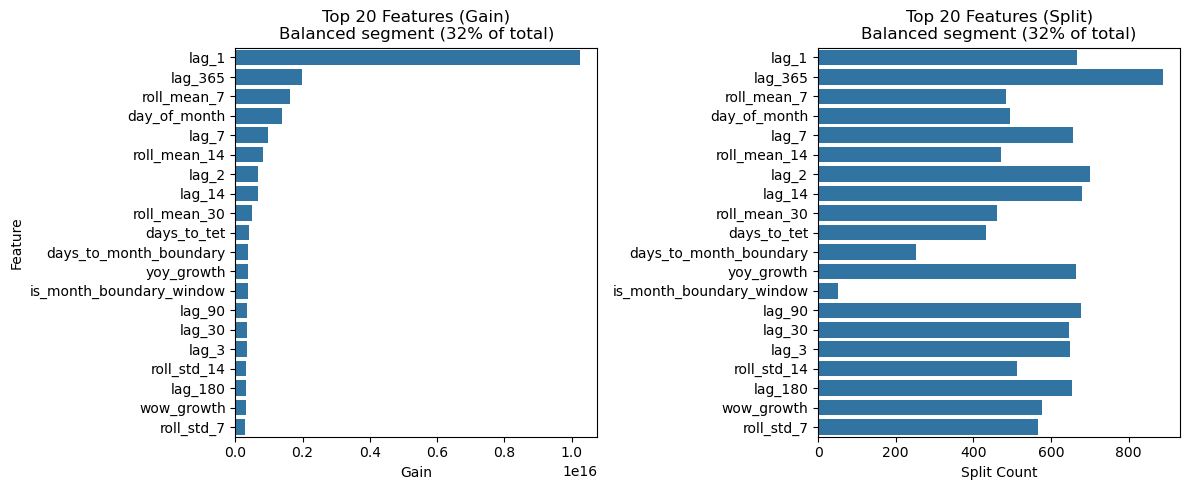

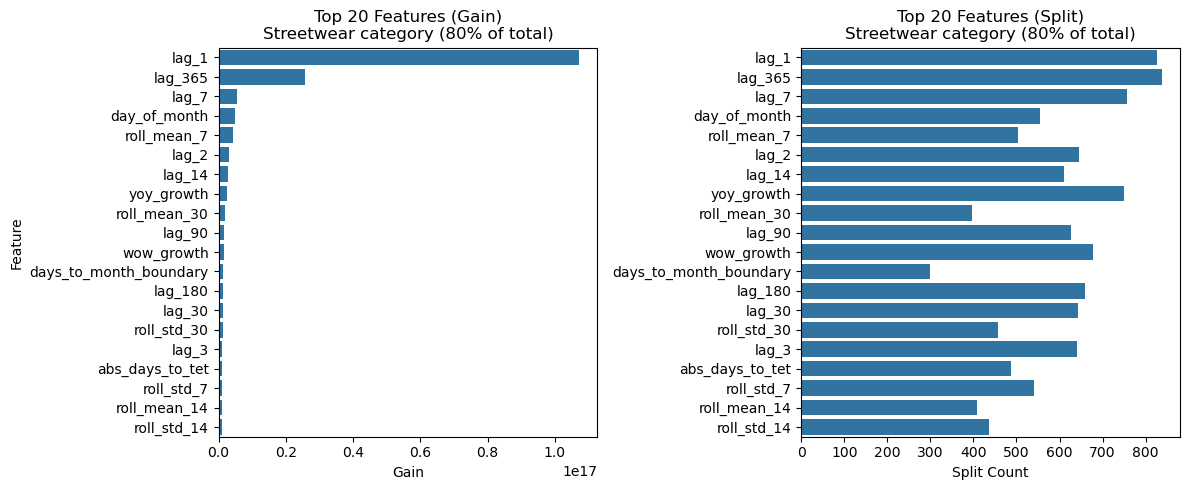


Vị trí xếp hạng (Balanced segment model)

  Tết features:
    rank #10   days_to_tet                gain=400,810,545,381,376
    rank #21   abs_days_to_tet            gain=251,254,888,243,200
    rank #43   is_tet_week                gain=           0
    rank #42   is_tet_holiday_period      gain=           0
    rank #40   is_tet_pre_ramp            gain=605,237,018,624

  Ranh giới tháng features:
    rank #13   is_month_boundary_window   gain=373,198,838,767,616
    rank #32   is_mid_month_low           gain=96,424,177,991,680
    rank #11   days_to_month_boundary     gain=378,715,402,973,184
    rank #33   month_boundary_intensity   gain=89,903,565,803,520
    rank #38   is_first_3_days            gain=17,351,682,482,176
    rank #37   is_last_4_days             gain=22,318,202,961,920


In [16]:
# Global feature importance
def show_importance(model, feat_cols, label, top_n=20):
    imp = pd.DataFrame({
        'feature': feat_cols,
        'gain':    model.feature_importance(importance_type='gain'),
        'split':   model.feature_importance(importance_type='split'),
    }).sort_values('gain', ascending=False).reset_index(drop=True)

    top_imp = imp.head(top_n)

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gain plot
    sns.barplot(
        data=top_imp,
        y='feature',
        x='gain',
        ax=axes[0]
    )
    axes[0].set_title(f"Top {top_n} Features (Gain)\n{label}")
    axes[0].set_xlabel("Gain")
    axes[0].set_ylabel("Feature")

    # Split plot
    sns.barplot(
        data=top_imp,
        y='feature',
        x='split',
        ax=axes[1]
    )
    axes[1].set_title(f"Top {top_n} Features (Split)\n{label}")
    axes[1].set_xlabel("Split Count")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()
    return imp

display_title("Feature importance với model dự đoán Balanced segment và Streetwear category theo chỉ số Gain và Split", pref='Figure', num=1)
imp_balanced   = show_importance(model_balanced,   fc_balanced,   "Balanced segment (32% of total)")
imp_streetwear = show_importance(model_streetwear, fc_streetwear, "Streetwear category (80% of total)")

# Vị trí xếp hạng của các feature được thiết kế (engineered features)
print(f"\n{'='*70}")
print("Vị trí xếp hạng (Balanced segment model)")
print(f"{'='*70}")
ENGINEERED = {
    'Tết':    ['days_to_tet','abs_days_to_tet','is_tet_week','is_tet_holiday_period','is_tet_pre_ramp'],
    'Ranh giới tháng':      ['is_month_boundary_window','is_mid_month_low','days_to_month_boundary','month_boundary_intensity',
                    'is_first_3_days','is_last_4_days']
}
for family, feats in ENGINEERED.items():
    print(f"\n  {family} features:")
    for f in feats:
        idx = imp_balanced.index[imp_balanced['feature']==f].tolist()
        if idx:
            print(f"    rank #{idx[0]+1:<3}  {f:<25}  gain={imp_balanced.loc[idx[0],'gain']:>12,.0f}")

### Insights từ Figure 1
- Các feature lag (lag_1, lag_365, lag_7,...) có đóng góp lớn nhất trong việc cải thiện độ chính xác của dự đoán ở gain lẫn xuất hiện nhiều nhất trong quá trình split data, qua đó cho thấy rằng model ML dựa phần lớn vào historical data trong cùng chuỗi thời gian (đặc trưng của time-series forecasting).
- Các feature được tạo thủ công từ data có sẵn (features của Tết, features của biên tháng) có đóng góp tích cực trong việc giảm loss của model -> chứng minh việc xem xét đến các yếu tố đặc trưng về lịch và mốc thời điểm trong tháng của Việt Nam là cần thiết.

Tính toán SHAP value (~30s/model)...


<br><p><span style="font-size: 1.2em;"><b>Figure 2</b>: Biểu đồ SHAP beeswarm miêu tả cho các features trong 2 model dự đoán Balanced segment và Streetwear category</span></p>

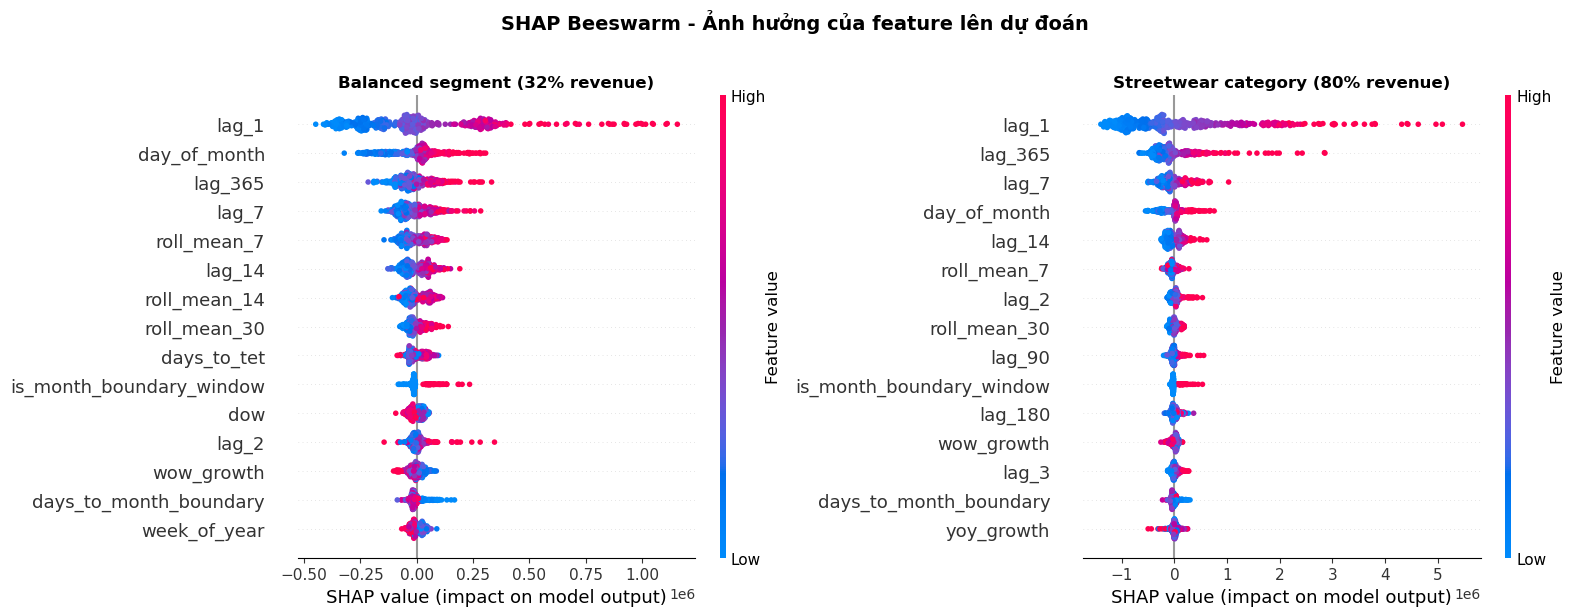

In [17]:
# SHAP summary plots
if shap is None:
    print("SHAP library chưa được cài đặt")
else:
    print("Tính toán SHAP value (~30s/model)...")

    explainer_b = shap.TreeExplainer(model_balanced)
    X_balanced = feat_balanced[fc_balanced]
    sample_idx_b = np.random.RandomState(RANDOM_SEED).choice(len(X_balanced), 500, replace=False)
    shap_values_b = explainer_b.shap_values(X_balanced.iloc[sample_idx_b])

    explainer_s = shap.TreeExplainer(model_streetwear)
    X_streetwear = feat_streetwear[fc_streetwear]
    sample_idx_s = np.random.RandomState(RANDOM_SEED).choice(len(X_streetwear), 500, replace=False)
    shap_values_s = explainer_s.shap_values(X_streetwear.iloc[sample_idx_s])

    # Set up the figure
    fig = plt.figure(figsize=(16, 6))
    display_title("Biểu đồ SHAP beeswarm miêu tả cho các features trong 2 model dự đoán Balanced segment và Streetwear category", pref='Figure', num=2)
    plt.subplot(1, 2, 1)
    shap.summary_plot(shap_values_b, X_balanced.iloc[sample_idx_b],
                      max_display=15, show=False, plot_size=None)
    plt.title('Balanced segment (32% revenue)', fontsize=12, fontweight='bold')

    plt.subplot(1, 2, 2)
    shap.summary_plot(shap_values_s, X_streetwear.iloc[sample_idx_s],
                      max_display=15, show=False, plot_size=None)
    plt.title('Streetwear category (80% revenue)', fontsize=12, fontweight='bold')

    plt.suptitle('SHAP Beeswarm - Ảnh hưởng của feature lên dự đoán', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
    plt.show()


### Insights từ Figure 2

- Streetwear category đóng góp phần lớn doanh thu và thể hiện hành vi mua sắm dựa trên xu hướng với biến động mạnh. lag_1 và lag_365 có ảnh hưởng lớn nhất trong nội bộ model và có ảnh hưởng gấp 5 lần so với các model khác cho thấy nhu cầu với hạng mục này có độ nhạy với đà tăng trưởng mạnh (độ bán chạy sản phẩm của thời gian trước là chỉ số dự báo tin cậy nhất cho ngày hôm nay). Tuy nhiên, việc dự đoán sai revenue cho category này cũng có ảnh hưởng rất lớn đến độ chính xác nói chung cho ensemble model.
- Balanced segment chịu sự ảnh hưởng của các feature lag tương tự như Streetwear, nhưng đồng thời cho thấy ảnh hưởng tích cực của các feature liên quan tới yếu tố đặc trưng của lịch tại Việt Nam như days_to_tet và thời gian cuối tháng. 

---
## 2.4 Submission Integrity Check


In [18]:
print("="*70)
print("KIỂM TRA INTEGRITY CỦA FILE SUBMISSION")
print("="*70)

submission_path = 'submission.csv'
if not os.path.exists(submission_path):
    print(f"  ERROR: {submission_path} not found.")
    print(f"  Run cell 1.7 first to generate it.")
else:
    sub = pd.read_csv(submission_path)

    with open(submission_path, 'rb') as f:
        sha256 = hashlib.sha256(f.read()).hexdigest()

    print(f"  File:         {submission_path}")
    print(f"  Số ngày:         {len(sub)}")
    print(f"  Ngày bắt đầu và kết thúc:   {sub['Date'].iloc[0]} -> {sub['Date'].iloc[-1]}")
    print(f"  Trung bình Revenue: {sub['Revenue'].mean():,.2f}")
    print(f"  Trung bình COGS:    {sub['COGS'].mean():,.2f}")
    print(f"\n  SHA-256:      {sha256}")


KIỂM TRA INTEGRITY CỦA FILE SUBMISSION
  File:         submission.csv
  Số ngày:         548
  Ngày bắt đầu và kết thúc:   2023-01-01 -> 2024-07-01
  Trung bình Revenue: 3,887,475.86
  Trung bình COGS:    3,451,051.81

  SHA-256:      464a606d3edb4153174cbc5c4ecf7b121c555621d57064137a71bed10b57b108


# Tổng kết

## 1. Các nội dung trong noteboook:

1. Pipeline ML nhất quán (Phần 1): mô hình được tạo end-to-end thông qua một luồng tuyến tính, có thể tái lập, không có bước ẩn
2. Tuân thủ luật thi (Mục 2.1): vượt qua 4 kiểm tra tự động theo quy định cuộc thi
3. Đã cross-validated (Mục 2.2): sử dụng rolling-origin CV cho chuỗi thời gian với MAE ổn định giữa các fold
4. Interpretability (Mục 2.3): phân tích SHAP ở cấp độ mô hình, trong đó các feature được thiết kế (Tết, payday) có thứ hạng hợp lý
5. Tính tái lập (Mục 2.4): phiên bản thư viện cụ thể, mã băm SHA-256 khớp với file đã nộp lên Kaggle

## 2. Các insights dành cho doanh nghiệp
- Lag features có vị trí quan trọng bậc nhất trong việc xây dựng các mô hình dự báo doanh thu dựa theo time-series. 
- Với các bộ data có thời gian trải dài và chỉ số cần dự đoán được cấu thành từ nhiều phân khúc, phân loại khác nhau, xây dựng model theo hướng bottom-up (đi từ phân tích các phân khúc, phân loại tách biệt trước để phát hiện các đặc điểm riêng) đến ensemble và trung bình hoá các dự đoán sẽ có hiệu quả tích cực.
- Yếu tố sử dụng đa lịch ở Việt Nam rất quan trọng (lịch dương + âm). Ngày Tết dịch chuyển khoảng ~20 ngày mỗi năm và gây ra mức giảm doanh thu kéo dài 7 ngày. Nếu không có feature Tết rõ ràng, mô hình sẽ dự báo sai một cách có hệ thống cho khoảng tháng 1 và tháng 2.